# 05 Method Comparison -- CI Bands, Metrics Table, and Rank Histograms

Loads all four ensemble CSVs (Bootstrap, GLUE, EnKF, LPU) produced in Phases 2â€“5,
computes probabilistic and deterministic metrics, displays a comparison table,
writes `method_comparison.csv`, renders a side-by-side 4-panel CI band plot (VIZ-02),
and generates per-method rank histograms (VIZ-03).

Does **not** re-run any UQ method - pure consumer of pre-exported ensemble CSVs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from red_tide_reanalysis.ingestion import load_observations, load_wam_model, align_obs_model
from red_tide_reanalysis.metrics import compute_all_methods
from red_tide_reanalysis.metrics.probabilistic import rank_histogram_values
from red_tide_reanalysis.writers import write_metrics_csv
from red_tide_reanalysis.core.result import EnsembleResult

## 1. Load and Align Observation and Model Data

In [2]:
obs_raw = load_observations("../Observation_Data/Observed_flow_ARCADIA_FL.csv")
wam_raw = load_wam_model("../Synthetic_Model_Data/Station 02296750 (ARCADIA)_reach000084_83.csv")
obs, model = align_obs_model(obs_raw, wam_raw)
print(f"Aligned series: {len(obs)} timesteps, {obs.index[0].date()} to {obs.index[-1].date()}")

Aligned series: 9131 timesteps, 1999-01-01 to 2023-12-31


## 2. Load All 4 Ensemble CSVs

In [3]:
data_dir = Path("data/outputs/ensembles")

csv_files = {
    "Bootstrap": "bootstrap_02296750_peace_river_discharge_members.csv",
    "GLUE": "glue_02296750_discharge_members.csv",
    "EnKF": "enkf_02296750_discharge_members.csv",
    "LPU": "lpu_02296750_discharge_members.csv",
}

methods = {}
for name, fname in csv_files.items():
    df = pd.read_csv(data_dir / fname, index_col=0, parse_dates=True)
    members = df.values.T  # CSV is (T, N); members must be (N, T)
    result = EnsembleResult(
        method_name=name.lower(),
        station_id="02296750",
        variable="discharge",
        time_index=pd.DatetimeIndex(df.index),
        members=members,
        observations=obs,
        model_output=model,
    )
    methods[name] = result

print(f"Loaded {len(methods)} methods: {list(methods.keys())}")
for name, r in methods.items():
    print(f"  {name}: {r.members.shape[0]} members, {r.members.shape[1]} timesteps")

Loaded 4 methods: ['Bootstrap', 'GLUE', 'EnKF', 'LPU']
  Bootstrap: 200 members, 9131 timesteps
  GLUE: 200 members, 9131 timesteps
  EnKF: 200 members, 9131 timesteps
  LPU: 200 members, 9131 timesteps


## 3. Compute Metrics Table

In [4]:
metrics_df = compute_all_methods(methods, obs)
display(metrics_df.round(4))

,method,crps,crpss,coverage_prob,spread_skill_ratio,kge,nse
0,Bootstrap,7.8480,0.7185,0.8953,0.7717,0.8701,0.8509
1,GLUE,7.6311,0.7262,0.9414,1.0209,0.8740,0.8611
2,EnKF,3.8879,0.8605,0.3778,0.4403,0.9383,0.9634
3,LPU,9.1001,0.6735,0.0847,0.0141,0.9003,0.8641


## 4. Write Metrics CSV

In [5]:
output_dir = Path("data/outputs/stats")
csv_path = write_metrics_csv(metrics_df, output_dir)
print(f"Metrics CSV written to: {csv_path}")

Metrics CSV written to: data\outputs\stats\method_comparison.csv


## 5. Side-by-Side CI Band Plot — 4 Methods (VIZ-02)

2×2 grid subplots with shared x-axis. 5th–95th percentile band only (no inner 25th–75th band).

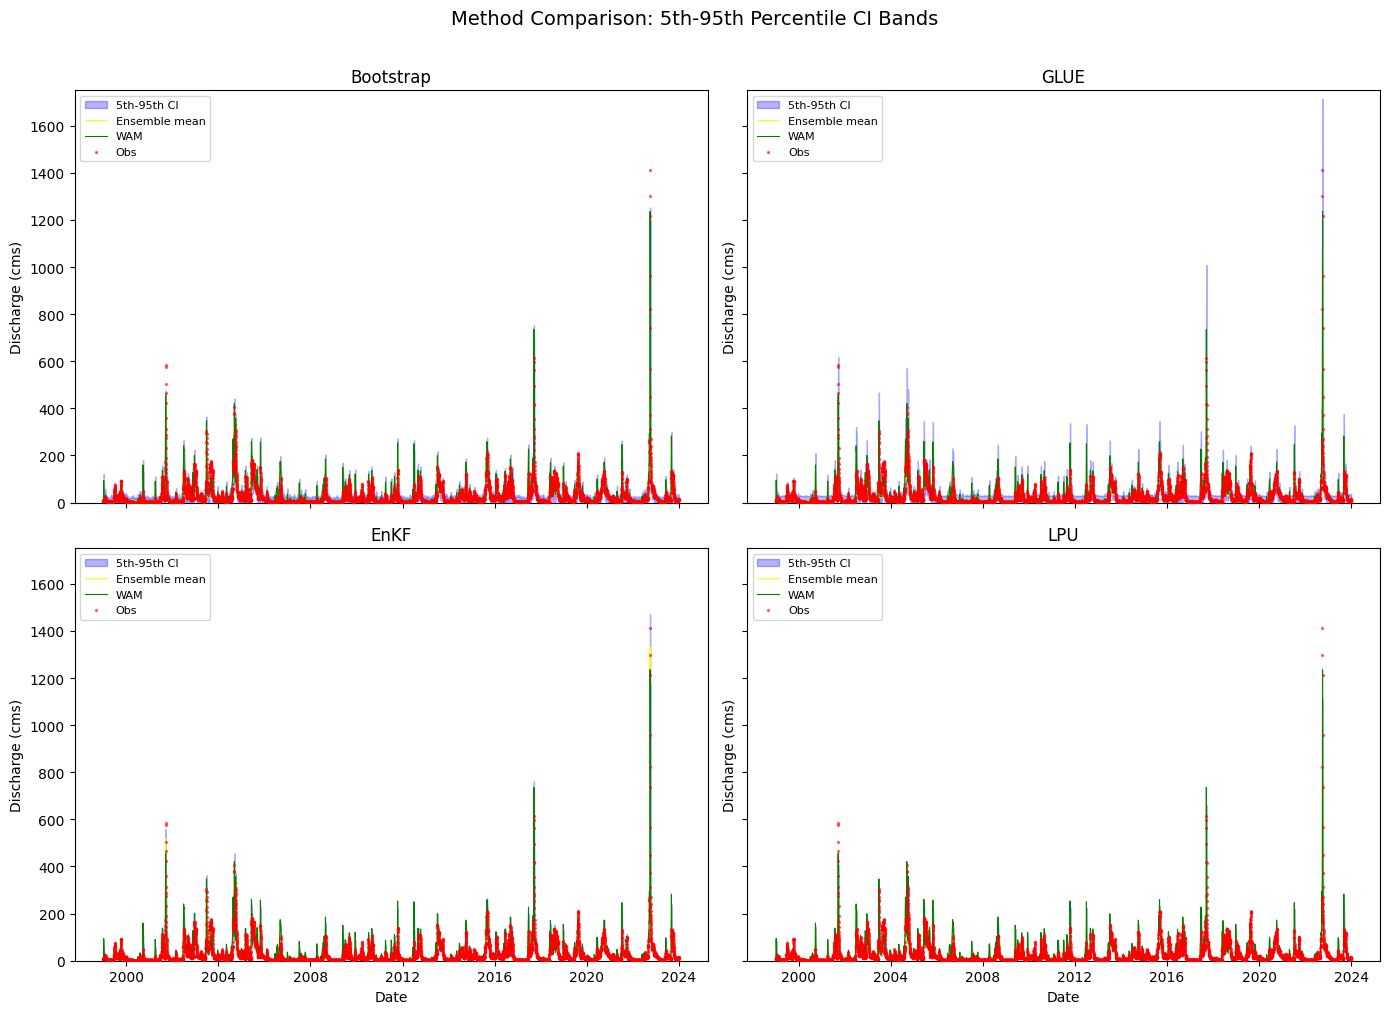

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
fig.suptitle("Method Comparison: 5th-95th Percentile CI Bands", fontsize=14, y=1.01)
axes_flat = axes.flatten()

for ax, (name, result) in zip(axes_flat, methods.items()):
    members = result.members
    q05 = np.percentile(members, 5, axis=0)
    q95 = np.percentile(members, 95, axis=0)
    mean = members.mean(axis=0)
    dates = result.time_index

    ax.fill_between(dates, q05, q95, alpha=0.3, color='blue', label='5th-95th CI')
    ax.plot(dates, mean, color='yellow', linewidth=0.8, label='Ensemble mean')
    ax.plot(dates, result.model_output.values, color='green', linewidth=0.8, label='WAM')
    ax.scatter(dates, result.observations.values, s=2, color='red', alpha=0.5, label='Obs', zorder=5)
    ax.set_ylabel("Discharge (cms)")
    ax.set_title(name)
    ax.set_ylim(0, 1750)
    ax.legend(loc='upper left', fontsize=8)

for ax in axes[1]:
    ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

## 6. Rank Histograms — Talagrand Diagrams (VIZ-03)

2×2 grid. 20 bins ( ECMWF operational default). Red dashed uniform reference line.

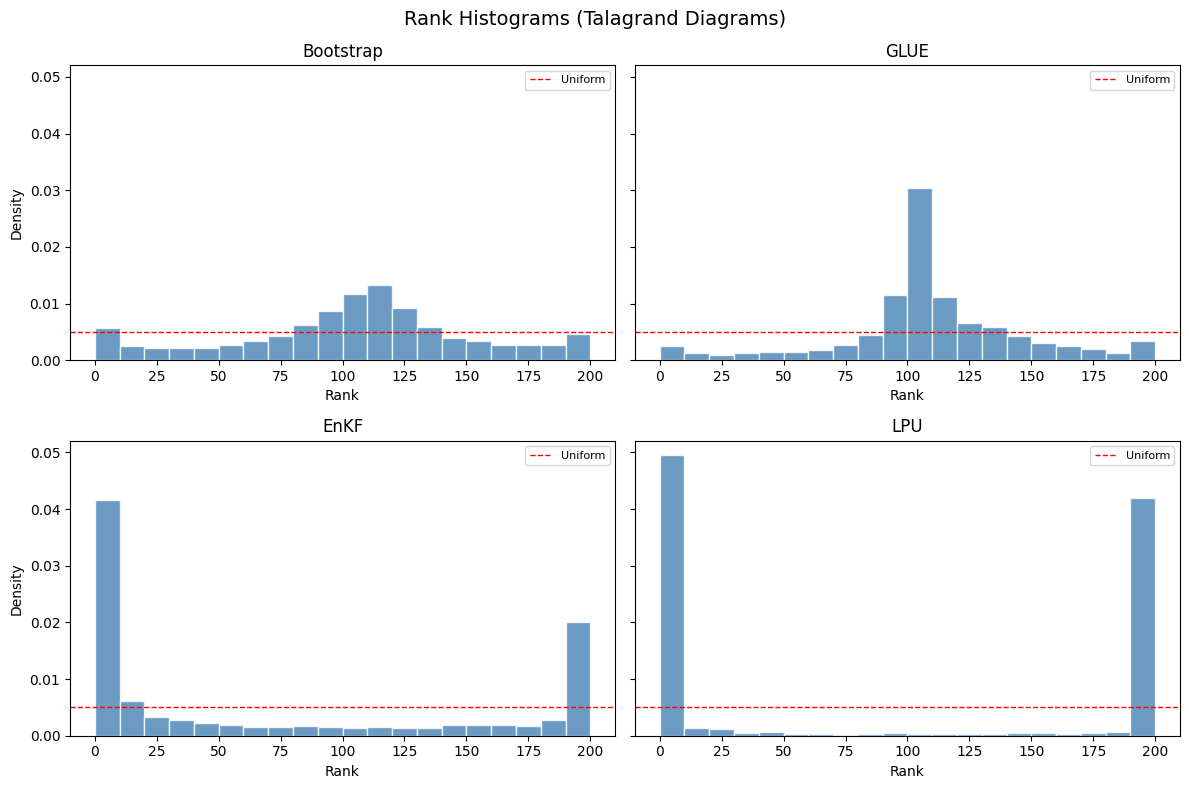

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
fig.suptitle("Rank Histograms (Talagrand Diagrams)", fontsize=14)
axes_flat = axes.flatten()

for ax, (name, result) in zip(axes_flat, methods.items()):
    ranks = rank_histogram_values(result.members, result.observations.values)
    N = result.members.shape[0]
    bins = np.linspace(0, N, 21)  # 20 bins
    ax.hist(ranks, bins=bins, density=True, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axhline(1.0 / N, color='red', linestyle='--', linewidth=1.0, label='Uniform')
    ax.set_title(name)
    ax.set_xlabel("Rank")
    ax.legend(fontsize=8)

for ax in axes[:, 0]:
    ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

## Summary

- **Data source**: Pre-exported ensemble CSVs from Phases 2â€“5 (no UQ methods re-run)
- **Methods compared**: Bootstrap, GLUE, EnKF, LPU
- **Metrics**: CRPS, CRPSS, coverage_prob (5thâ€“95th), spread_skill_ratio, KGE, NSE
- **Outputs**: `data/outputs/stats/method_comparison.csv`
- **Plots**: 4-panel CI band comparison (VIZ-02); 4-panel rank histograms (VIZ-03)